# Vanishing-Act 🎩
### "Small-caps beat large-caps" — the factor that launched an industry, on the tape

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survived publication?: Busted](https://img.shields.io/badge/Survived_publication%3F-Busted-8b949e?style=flat-square)

The size premium is finance's oldest factor: Banz showed in 1981 that small companies out-earn big ones, and a thousand small-cap funds followed. We test it on the longest free data — the Russell 2000 vs the S&P 500 back to 1987. Over 39 years the premium is **zero**, small-caps actually *trail* on a risk-adjusted basis, and the sign of any "decade of small-cap outperformance" depends entirely on which decade you pick. And note the dates: the data starts six years *after* the paper — everything you're about to see is post-publication.

> 📓 **Plain-language layer.** The t-stats, the aligned-sample discipline and the window-split bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (vanishing_act/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from vanishing_act import data, strategy as st
from quantlab import repro
ret = repro.as_of(data.fetch_pairs())          # cache-first, pinned to the desk as-of
smb_long = st.smb(ret, "^RUT", "^GSPC")        # the long-history spread (price indices — conservative)


## The answer first 🎯

| The belief | The tape |
|---|---|
| "Small-caps earn a premium" | Russell 2000 − S&P 500 = **+0.03%/yr over 39 years** (t = 0.02). |
| "…for taking more risk" | On the same months, small-caps' **Sharpe is lower** (0.47 vs 0.62). |
| "It worked until everyone piled in" | The whole sample is *post*-publication — and it never worked in it. The sign flips with the window. |

## 1 · The claim

Banz (1981): the smallest stocks earn higher returns than the largest, even after adjusting for market risk — the **size premium**, the SMB factor in every textbook model, the rationale for small-cap allocations everywhere.

## 2 · So what?

If small beats big, every investor should tilt small. If the premium can't be found in four decades of post-publication data, then a core piece of portfolio orthodoxy is anchored on a result nobody has been able to reproduce out of sample.

## 3 · How would we even know?

Take the longest free proxy — Russell 2000 minus S&P 500, 1987–2026 — measure the spread and its t-stat, compare each side's standalone Sharpe **on the same months**, and ask whether any sub-period 'premium' survives an honest test of window luck. (The index pair is price-only; large caps pay more dividends, so a total-return spread would look *worse* for size — the test is tilted in the premium's favour.)

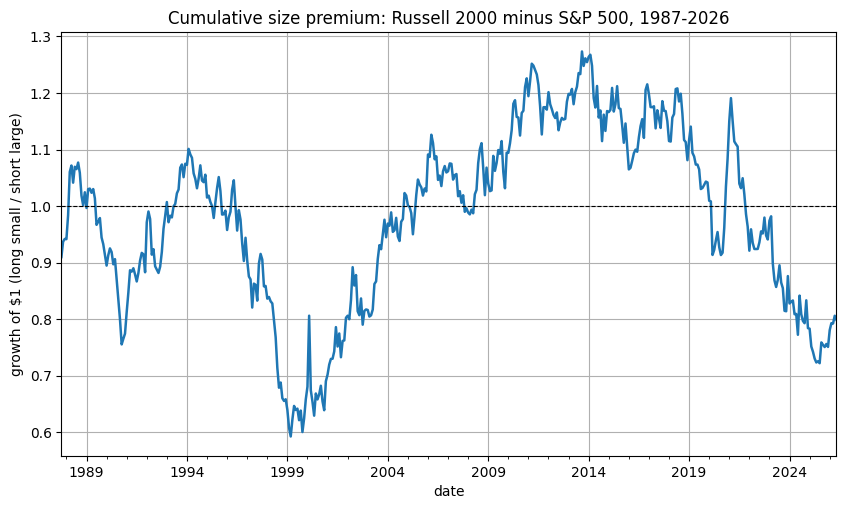

39-year SMB: +0.03%/yr, Sharpe 0.00, Lo t=0.02


In [2]:
eq=(1+smb_long).cumprod()
ax=eq.plot(title='Cumulative size premium: Russell 2000 minus S&P 500, 1987-2026',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1 (long small / short large)'); plt.show()
s=st.smb_stats(smb_long); print(f"39-year SMB: {s['mean_ann']:+.2%}/yr, Sharpe {s['sharpe']:.2f}, Lo t={s['tstat']:.2f}")

## 4 · The teardown

A line that wanders for four decades and ends where it started. And because "it worked before 2010" is the usual rescue, here is the trailing ten-year premium — the thing a fund brochure would show you — for every possible ending month.

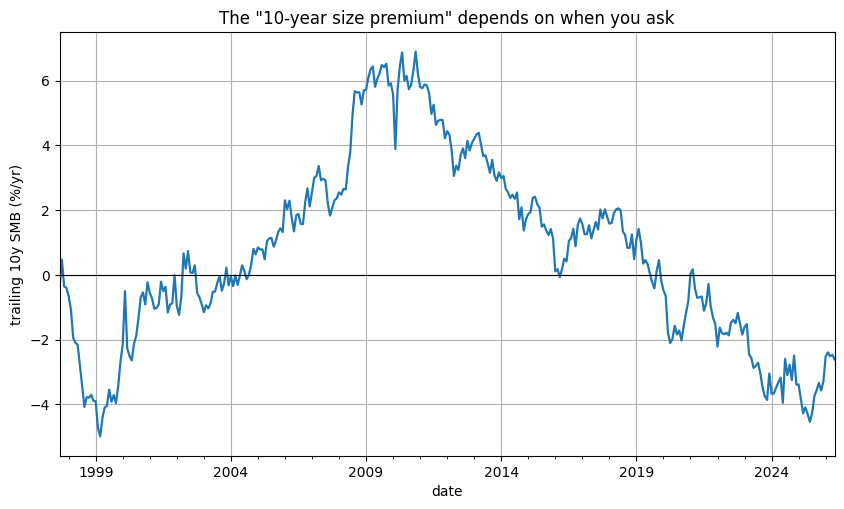

range -5.0% to +6.9%/yr; positive in 56% of windows


In [3]:
roll=st.rolling_mean_ann(smb_long,120).dropna()
ax=(roll*100).plot(lw=1.6,title='The "10-year size premium" depends on when you ask')
ax.axhline(0,color='k',lw=.8); ax.set_ylabel('trailing 10y SMB (%/yr)'); plt.show()
print(f'range {roll.min():+.1%} to {roll.max():+.1%}/yr; positive in {(roll>0).mean():.0%} of windows')

**Read it plainly.** The "premium" swings from −5%/yr to +7%/yr and crosses zero again and again. Pick an ending month and you can prove smallness pays, or that it costs you — which is another way of saying there is no premium, just windows.

## 5 · The verdict

**Signal: None** — zero over 39 years, small-caps even trailing on Sharpe. **Tradability: Mirage** — nothing to harvest. **Survived publication?: Busted** — every month of this sample postdates Banz 1981, and the premium never showed.

## 6 · Could you actually trade it?

You can buy a small-cap ETF cheaply — but you'd be buying a *lower* Sharpe than the S&P 500, not a premium. The only version with a faint pulse (the S&P 600) earns it by screening for profitable companies — that's a quality bet, not a size one.

## 7 · Going further 🚪

The quants notebook adds the Lo t-stats, the aligned-sample discipline, the bootstrap on the 2010 split, and the quality caveat (Asness et al. 2018, *Size Matters, If You Control Your Junk*). This closes the five-study debunk bench from the [paperswithbacktest backlog](../../../docs/pwb_strategies_inventory.md).